<a href="https://colab.research.google.com/github/ceothinkmaking-code/Llama3-Test/blob/main/Quant_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**https://github.com/finterstellar/quant_machine**



https://finterstellar.com/#google_vignette
OTP 받으려면 회원가입 및및 로그인

https://mybinder.org/v2/gh/finterstellar/recipe/master



https://www.sec.gov/submit-filings

https://dart.fss.or.kr/

https://stockrow.com/

https://stockrow.com/AAPL  stockrow.com 사이트를 크롤링해서 자체적으로 데이터베이스를 구성해 놓고 쓰면 됨, 혹은  finterstellar.com 사이트에서 OTP 발급받아서 사용 => finterstellar.com/api/single?otp=<OTP code>&symbol=<종목코드> 를 웹브라우저에 입력하면 해당 종목의 10년치 분기별 재무제표 데이터 반환됨

In [ ]:
!pip install finterstellar==0.1.10
!pip install pandas-datareader==0.10.0


In [ ]:
import finterstellar as fs

In [ ]:
df = fs.get_price('AAPL', start_date='2020-01-01', end_date='2020-12-31')

In [ ]:
print(df)

             AAPL
2020-01-02  72.40
2020-01-03  71.70
2020-01-06  72.27
2020-01-07  71.93
2020-01-08  73.09
...           ...
2020-12-24 128.35
2020-12-28 132.94
2020-12-29 131.17
2020-12-30 130.05
2020-12-31 129.05

[253 rows x 1 columns]


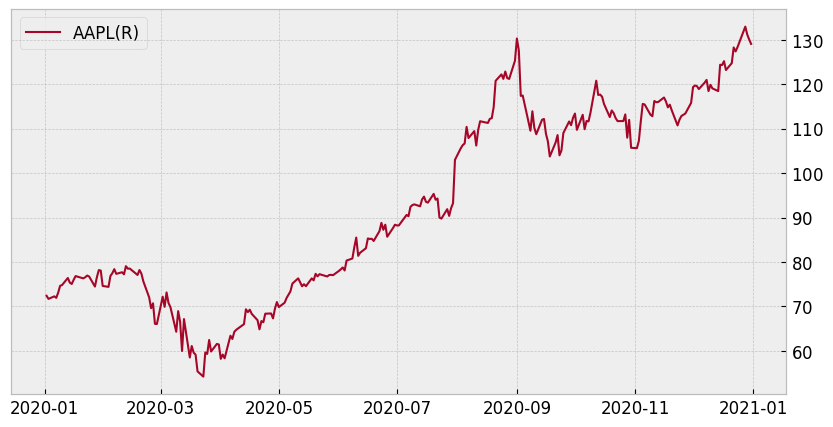

In [ ]:
fs.draw_chart(df, right='AAPL')

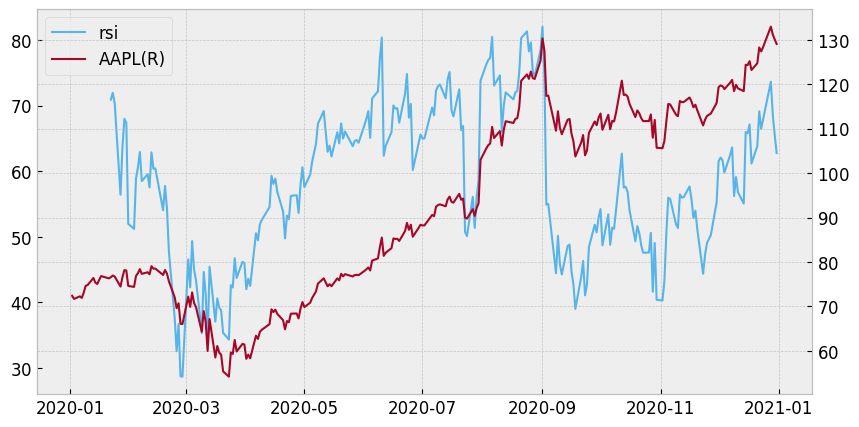

In [ ]:
fs.rsi(df, w=14)
fs.draw_chart(df, left='rsi', right='AAPL')

In [ ]:
fs.indicator_to_signal(df, factor='rsi', buy=40, sell=60)

,trade
2020-01-02,zero
2020-01-03,zero
2020-01-06,zero
2020-01-07,zero
2020-01-08,zero
...,...
2020-12-24,zero
2020-12-28,zero
2020-12-29,zero
2020-12-30,zero


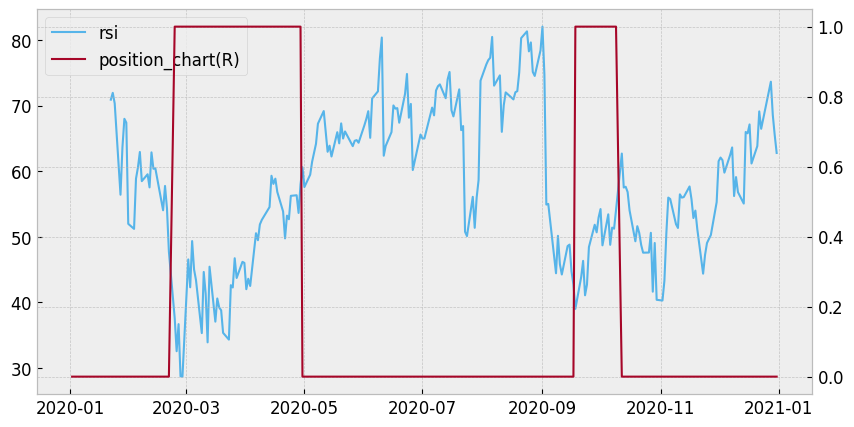

In [ ]:
fs.position(df)
fs.draw_chart(df, left='rsi', right='position_chart')

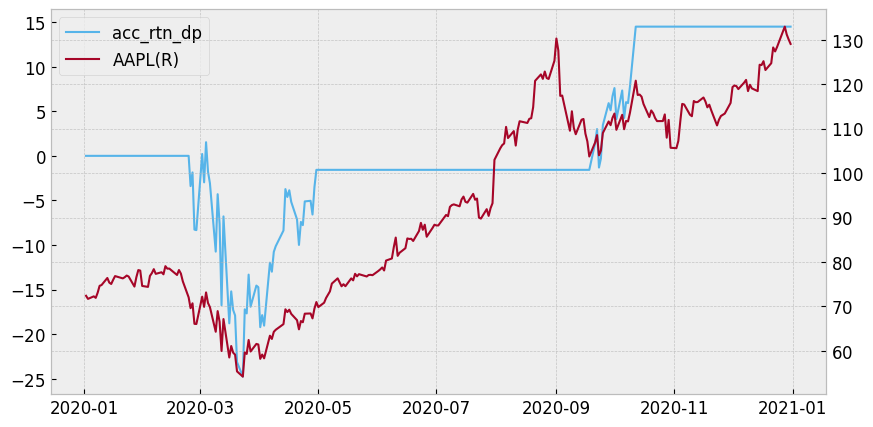

In [ ]:
fs.evaluate(df, cost=.001)
fs.draw_chart(df, left='acc_rtn_dp', right='AAPL')

In [ ]:
fs.performance(df, rf_rate=0.01)

CAGR: 15.37%
Accumulated return: 14.49%
Average return: 7.38%
Benchmark return : 68.52%
Number of trades: 2
Number of win: 1
Hit ratio: 50.00%
Investment period: 0.9yrs
Sharpe ratio: 0.33
MDD: -25.89%
Benchmark MDD: -31.43%


CAGR: 48.69%
Accumulated return: 45.89%
Average return: 45.97%
Benchmark return : 68.52%
Number of trades: 2
Number of win: 1
Hit ratio: 50.00%
Investment period: 0.9yrs
Sharpe ratio: 1.29
MDD: -30.45%
Benchmark MDD: -31.43%


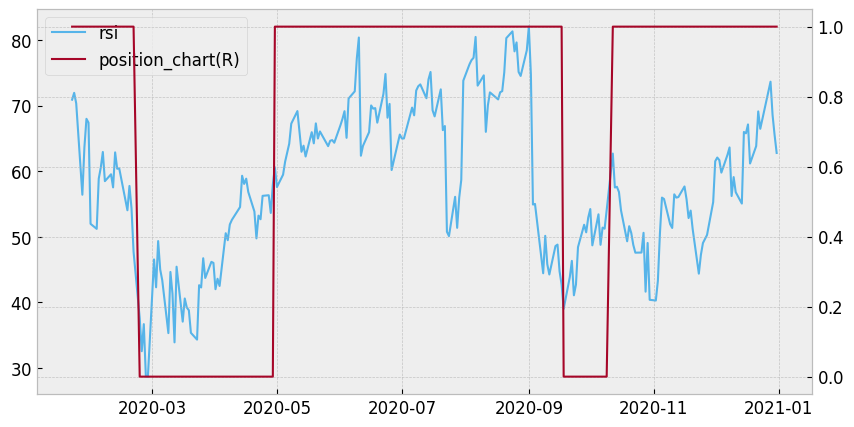

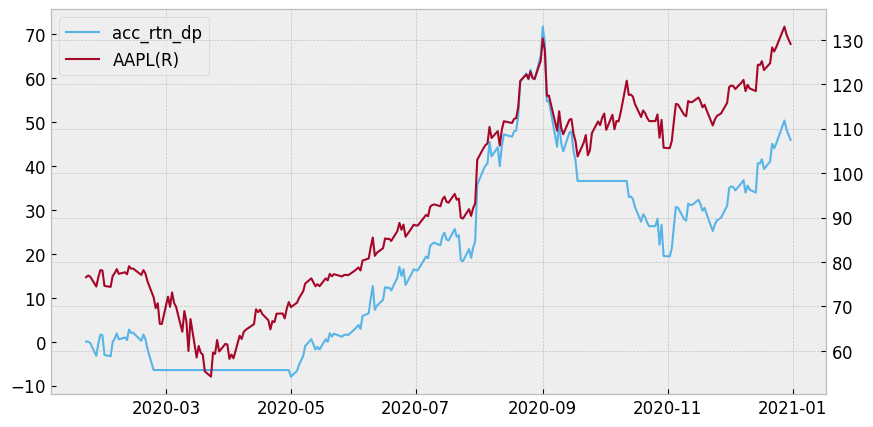

In [ ]:
fs.indicator_to_signal(df, factor='rsi', buy=60, sell=40)
fs.position(df)
fs.evaluate(df, cost=.001)
fs.performance(df, rf_rate=0.01)
fs.draw_chart(df, left='rsi', right='position_chart')
fs.draw_chart(df, left='acc_rtn_dp', right='AAPL')


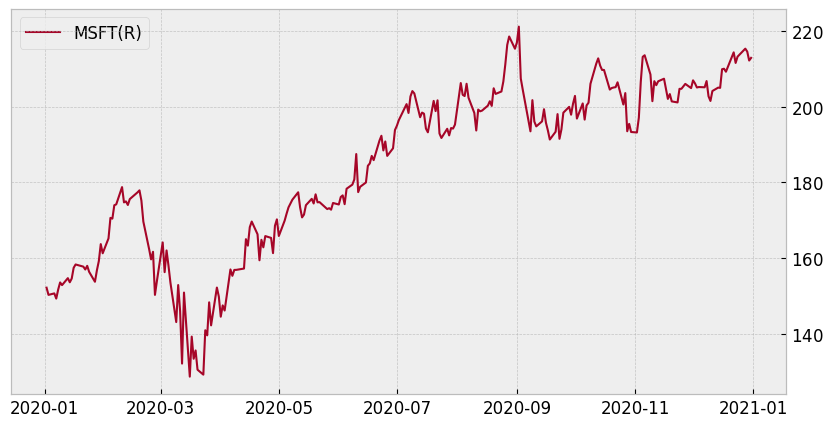

In [ ]:
#import finterstellar as fs
symbol = 'MSFT'
df = fs.get_price(symbol, start_date='2020-01-01', end_date='2020-12-31')
fs.draw_chart(df, right=symbol)

,trade
2020-01-02,zero
2020-01-03,zero
2020-01-06,zero
2020-01-07,zero
2020-01-08,buy
...,...
2020-12-24,buy
2020-12-28,buy
2020-12-29,buy
2020-12-30,buy


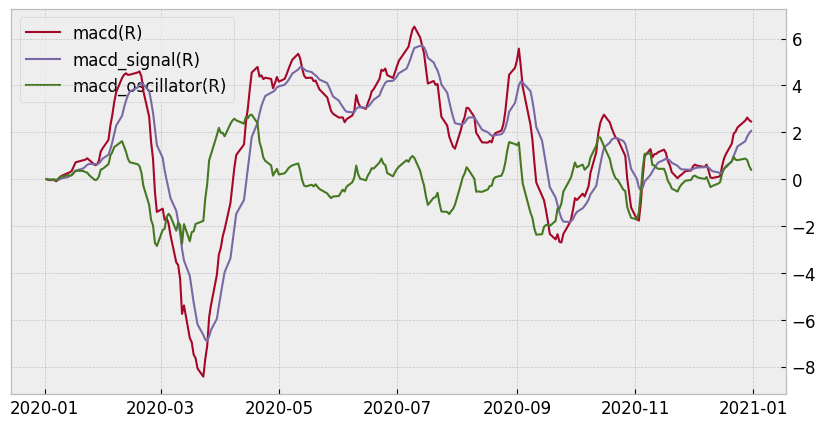

In [ ]:
fs.macd(df)
fs.draw_chart(df, right=['macd', 'macd_signal', 'macd_oscillator'])
fs.indicator_to_signal(df, factor='macd_oscillator', buy=0, sell=0)

In [ ]:
df.loc['2020-10-01':'2020-10-10']

,MSFT,ema_short,ema_long,macd,macd_signal,macd_oscillator,trade
2020-10-01,202.87,198.63,199.43,-0.81,-1.52,0.71,buy
2020-10-02,196.88,198.36,199.25,-0.89,-1.40,0.51,buy
2020-10-05,200.88,198.75,199.37,-0.62,-1.24,0.62,buy
2020-10-06,196.61,198.42,199.16,-0.74,-1.14,0.40,buy
2020-10-07,200.36,198.72,199.25,-0.53,-1.02,0.49,buy
2020-10-08,201.07,199.08,199.39,-0.31,-0.88,0.57,buy
2020-10-09,206.07,200.15,199.88,0.27,-0.65,0.92,buy


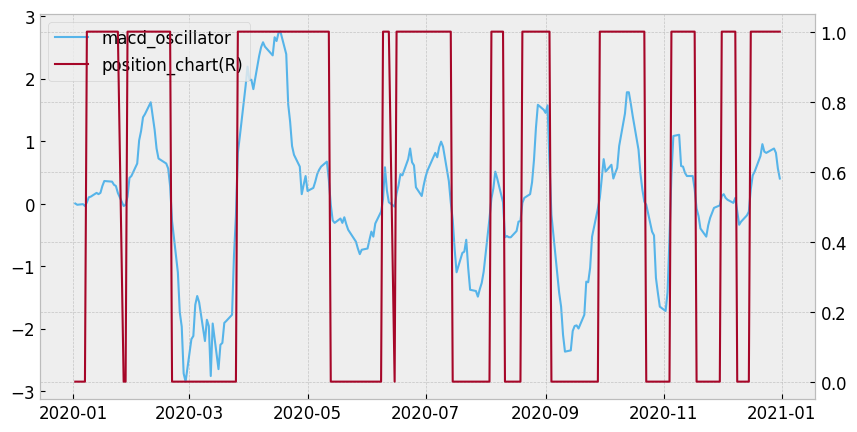

In [ ]:
fs.position(df)
fs.draw_chart(df, right='position_chart', left='macd_oscillator')

CAGR: 23.25%
Accumulated return: 23.25%
Average return: 2.14%
Benchmark return : 39.94%
Number of trades: 11
Number of win: 5
Hit ratio: 45.45%
Investment period: 1.0yrs
Sharpe ratio: 0.76
MDD: -11.29%
Benchmark MDD: -28.04%


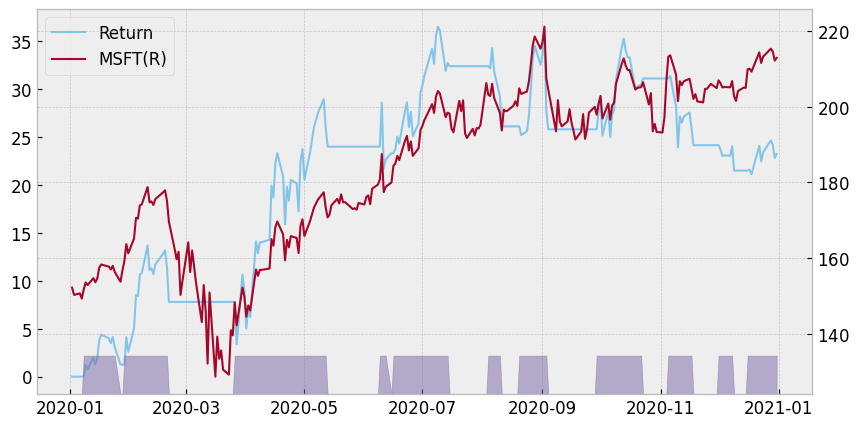

In [ ]:
fs.evaluate(df, cost=.001)
fs.performance(df, rf_rate=0.01)
fs.draw_trade_results(df)

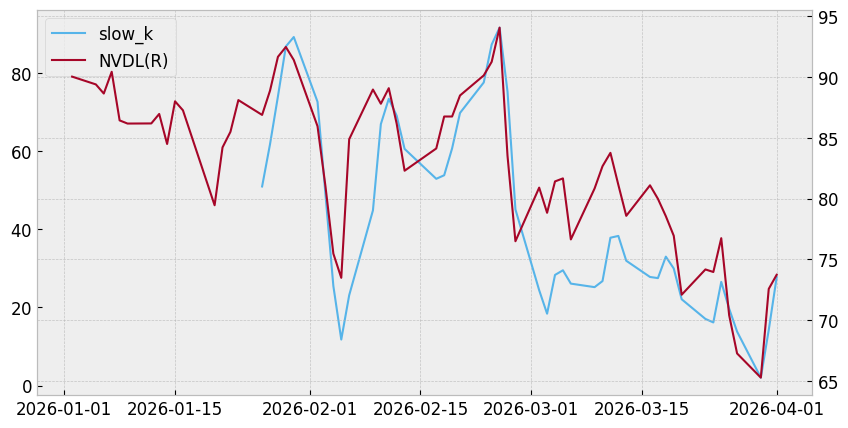

In [ ]:

# 델타에어라인
#symbol='DAL'
symbol='NVDL'
df = fs.get_ohlc(symbol, start_date='2026-01-01', end_date='2026-04-02')
df.tail()
fs.stochastic(df, symbol, n=14, m=3, t=3)

fs.draw_chart(df, left='slow_k', right=symbol)